# PyPSA-Earth Results


> This notebook organises system results from a PyPSA-Earth run into publication-ready figures and tables.
> It includes helper functions to avoid repetition and inline technical comments for reproducibility.

## Reproducibility & Environment
Run this cell to print versions and paths. Keep it in the paper's supplementary information.

In [25]:
# === CORE SCIENTIFIC STACK ===
import os
import sys
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Wedge, Patch
from matplotlib.lines import Line2D
import matplotlib as mpl

# === PYPSA ===
import pypsa
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches

# === FILESYSTEM / PATHS ===
from pathlib import Path

# === GEOSPATIAL (optional, used for maps) ===
try:
    import geopandas as gpd
    import cartopy.crs as ccrs
    from shapely.geometry import Point, LineString, box
    GIS_AVAILABLE = True
except:
    GIS_AVAILABLE = False
    print("⚠️ GIS modules not available (maps disabled)")

# === INTERACTIVE GRAPHICS (optional) ===
try:
    import plotly.express as px
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
except:
    PLOTLY_AVAILABLE = False
    print("⚠️ Plotly not available (interactive disabled)")

# === MISC UTILS ===
import warnings
warnings.filterwarnings("ignore")
from functools import reduce
from collections import defaultdict, OrderedDict
from IPython.display import display, HTML, Markdown


## Helper Functions
Avoid repeating boilerplate in map figures. These helpers standardise styles and reduce errors.

In [26]:
from IPython.display import Markdown, display
import matplotlib as mpl
from matplotlib.patches import Wedge, Patch

def get_bus_gdf(n):
    """GeoDataFrame of buses with WGS84 coordinates."""
    if 'x' not in n.buses.columns or 'y' not in n.buses.columns:
        raise ValueError("Network buses must have x,y coordinates.")
    return gpd.GeoDataFrame(
        n.buses.copy(),
        geometry=gpd.points_from_xy(n.buses.x, n.buses.y),
        crs="EPSG:4326",
    )

def get_line_gdf(n):
    """GeoDataFrame of AC lines as LineStrings."""
    if n.lines.empty:
        return gpd.GeoDataFrame(columns=['geometry'], geometry=[], crs="EPSG:4326")
    geoms = [
        LineString([(n.buses.loc[row.bus0].x, n.buses.loc[row.bus0].y),
                    (n.buses.loc[row.bus1].x, n.buses.loc[row.bus1].y)])
        for _, row in n.lines.iterrows()
    ]
    gdf = gpd.GeoDataFrame(n.lines.copy(), geometry=geoms, crs="EPSG:4326")
    return gdf

def map_axes(title:str, n, figsize=(10,8)):
    """Create a Cartopy PlateCarree axis with coastlines and extent fitted to the network area."""
    if not GIS_AVAILABLE:
        raise RuntimeError("GIS modules (geopandas/cartopy) are required for maps.")
    fig, ax = plt.subplots(figsize=figsize, subplot_kw={"projection": ccrs.PlateCarree()})
    ax.set_title(title)
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True, linewidth=0.2)
    # Fit extent with padding
    padx, pady = 2, 2
    ax.set_extent([n.buses.x.min()-padx, n.buses.x.max()+padx,
                   n.buses.y.min()-pady, n.buses.y.max()+pady])
    return fig, ax

def scalar_colorbar(ax, vmin, vmax, cmap="viridis", label=""):
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
    sm._A = []
    cbar = plt.colorbar(sm, ax=ax, fraction=0.035, pad=0.04)
    if label: cbar.set_label(label)
    return cbar

def carrier_colors(series_or_cols):
    cols = list(series_or_cols)
    cmap = plt.cm.tab20(np.linspace(0,1,max(1,len(cols))))
    return dict(zip(cols, cmap))

## Load Network
Update `path` to point to your `.nc` results file if needed.

In [27]:
path = r"C:\Users\Lella\Documents\UNI\PyPSA\pypsa-earth\results\networks\elec_s_20_ec_lcopt_Co2L-4H.nc"
n = pypsa.Network(path)
n
print(n.generators.carrier.unique())
print(n.carriers.index)

INFO:pypsa.io:Imported network elec_s_20_ec_lcopt_Co2L-4H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


['CCGT' 'nuclear' 'onwind' 'ror' 'solar' 'offwind-ac' 'offwind-dc' 'coal'
 'geothermal' 'oil' 'load shedding']
Index(['oil', 'geothermal', 'coal', 'nuclear', 'OCGT', 'lignite', 'biomass',
       'CCGT', 'hydro', 'offwind-ac', 'offwind-dc', 'onwind', 'solar', 'PHS',
       'ror', 'AC', 'DC', 'B2B', 'H2', 'battery', 'battery discharger',
       'H2 electrolysis', 'H2 fuel cell', 'battery charger', 'load shedding'],
      dtype='object', name='Carrier')


## Basic Summary
Quick checks before analysis.

In [28]:
print("Objective (total cost):", getattr(n, "objective", None))
print("Snapshots:", n.snapshots[0], "→", n.snapshots[-1], f"({len(n.snapshots)} steps)")
print("Total demand (MWh):", float(n.loads_t.p.sum().sum()))
try:
    print("CO₂ limit (Mt):", float(n.global_constraints.loc["CO2Limit","constant"])/1e6)
    print("CO₂ shadow price mu (€/t):", float(n.global_constraints.loc["CO2Limit","mu"]))
except Exception as e:
    print("CO₂ constraint not found:", e)

Objective (total cost): 5784302758.0
Snapshots: 2013-03-01 00:00:00 → 2013-03-06 20:00:00 (36 steps)
Total demand (MWh): 1404783.145008091
CO₂ limit (Mt): 0.1239816458729
CO₂ shadow price mu (€/t): -232.023


In [29]:
# Filtra il generatore nucleare
nuclear = n.generators.query("carrier == 'nuclear'")

# Mostra i costi effettivi che PyPSA ha usato
print(nuclear[["capital_cost", "marginal_cost", "efficiency"]])

                 capital_cost  marginal_cost  efficiency
Generator                                               
IT0 0 nuclear   753784.215297      14.024064       0.326
IT0 1 nuclear   753784.215297      14.023788       0.326
IT0 10 nuclear  753784.215297      14.024260       0.326
IT0 11 nuclear  753784.215297      14.024124       0.326
IT0 12 nuclear  753784.215297      14.022381       0.326
IT0 13 nuclear  753784.215297      14.022353       0.326
IT0 14 nuclear  753784.215297      14.022287       0.326
IT0 15 nuclear  753784.215297      14.022756       0.326
IT0 16 nuclear  753784.215297      14.022430       0.326
IT0 17 nuclear  753784.215297      14.022518       0.326
IT0 2 nuclear   753784.215297      14.022719       0.326
IT0 3 nuclear   753784.215297      14.023749       0.326
IT0 4 nuclear   753784.215297      14.022860       0.326
IT0 5 nuclear   753784.215297      14.023860       0.326
IT0 6 nuclear   753784.215297      14.023475       0.326
IT0 7 nuclear   753784.215297  

In [30]:
plants = pd.read_csv("resources/powerplants.csv")
print(plants["Fueltype"].unique())

['CCGT' 'Hydro' 'Hard Coal' 'Oil' 'Waste' 'Geothermal' 'nuclear']


## Transmission — Topology & Capacity

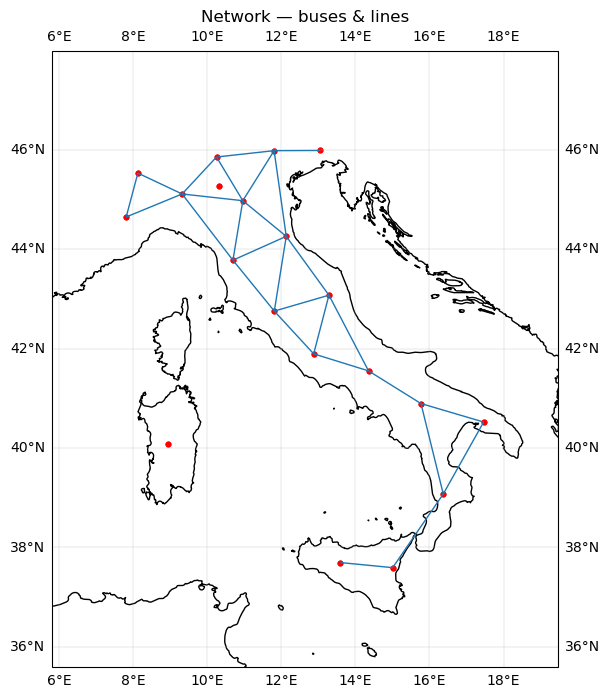

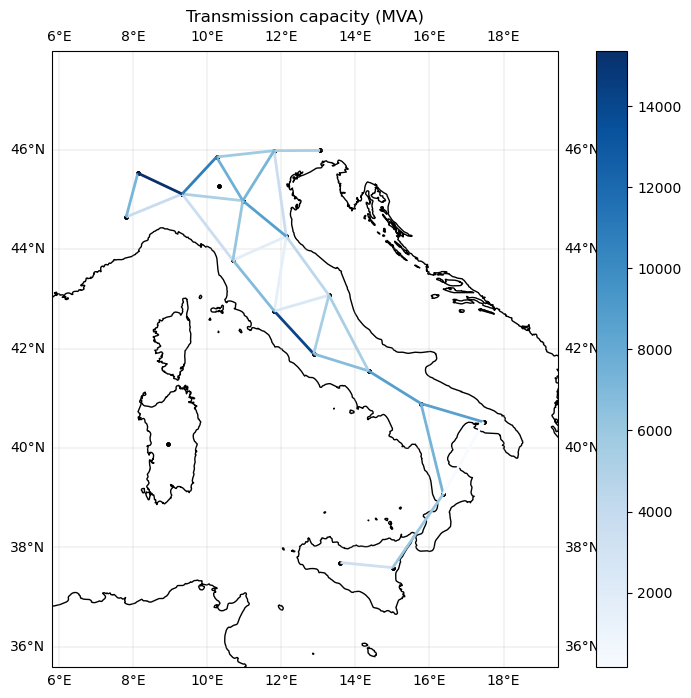

AC transmission (MVA): 174380.29599999997
HVDC transmission (MW): 4819.0


In [31]:
if GIS_AVAILABLE:
    bus_gdf = get_bus_gdf(n)
    line_gdf = get_line_gdf(n)

    # Topology
    fig, ax = map_axes("Network — buses & lines", n)
    if not line_gdf.empty:
        line_gdf.plot(ax=ax, linewidth=1)
    bus_gdf.plot(ax=ax, color="red", markersize=10)
    plt.show()

    # Capacity
    if "s_nom_opt" in n.lines:
        line_gdf["capacity"] = n.lines.s_nom_opt.values
    else:
        line_gdf["capacity"] = n.lines.s_nom.values
    fig, ax = map_axes("Transmission capacity (MVA)", n)
    if not line_gdf.empty:
        line_gdf.plot(ax=ax, column="capacity", cmap="Blues", linewidth=2, legend=True)
    bus_gdf.plot(ax=ax, color="black", markersize=5)
    plt.show()

    # Installed AC/DC totals
    ac = (n.lines.s_nom_opt if "s_nom_opt" in n.lines else n.lines.s_nom).sum()
    dc = n.links[getattr(n.links.carrier.str, "contains")("DC", case=False, na=False)].p_nom_opt.sum() if len(n.links)>0 else 0.0
    print("AC transmission (MVA):", float(ac))
    print("HVDC transmission (MW):", float(dc))
else:
    print("GIS not available — skipping maps.")

## Line Loading & Congestion

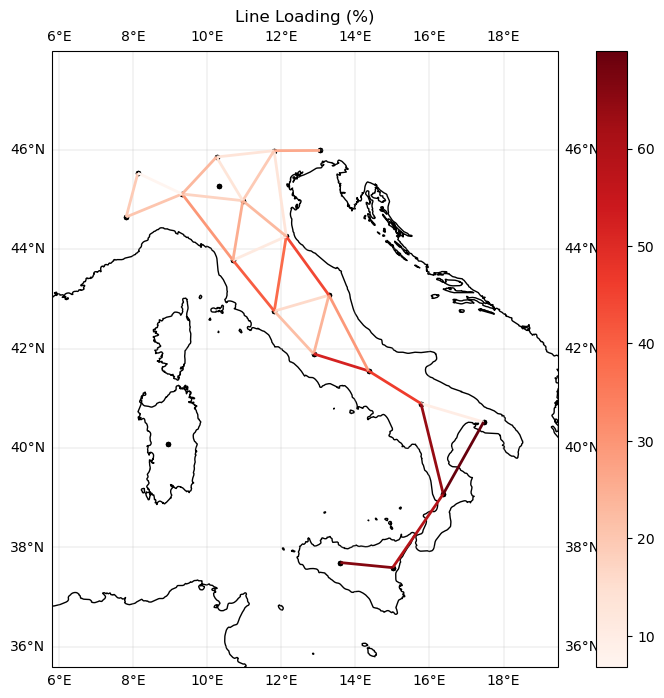

,loading_%
Line,
7,69.999916
13,66.133582
4,63.899569
12,58.816585
5,51.743730
2,46.197778
23,44.134176
21,40.373553
19,38.295610


In [32]:
if GIS_AVAILABLE and not n.lines.empty and not n.lines_t.p0.empty:
    loading = (n.lines_t.p0.abs().max() / n.lines.s_nom.replace(0, np.nan)) * 100
    line_gdf = get_line_gdf(n).assign(loading = loading.values)

    fig, ax = map_axes("Line Loading (%)", n)
    if not line_gdf.empty:
        line_gdf.plot(ax=ax, column="loading", cmap="Reds", linewidth=2, legend=True)
    get_bus_gdf(n).plot(ax=ax, color="black", markersize=8)
    plt.show()

    display(loading.sort_values(ascending=False).to_frame("loading_%").head(20))
else:
    print("Line loading not available.")

## System Capacity & Energy Mix

In [33]:
n.generators["type"].unique()


array([''], dtype=object)

,Installed capacity (MW)
type,
,202318.14


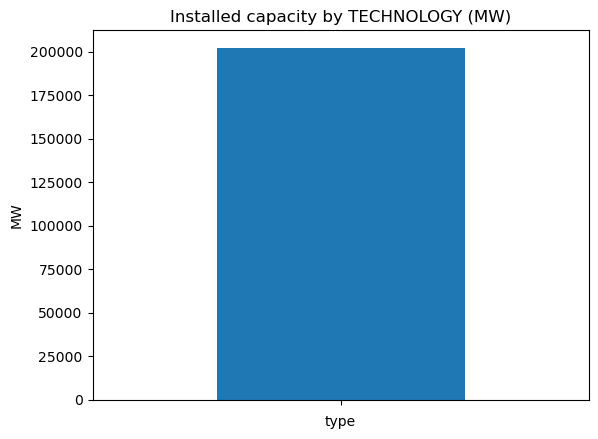

In [34]:
cap = n.generators.groupby("type").p_nom_opt.sum().sort_values(ascending=False)
display(cap.to_frame("Installed capacity (MW)").round(2))

cap.plot(kind="bar", title="Installed capacity by TECHNOLOGY (MW)")
plt.ylabel("MW")
plt.show()


,Installed capacity (MW)
carrier,
load shedding,55206.97
CCGT,47688.38
nuclear,40000.00
solar,34508.06
onwind,14424.08
coal,5830.00
ror,4231.60
oil,389.06
geothermal,40.00


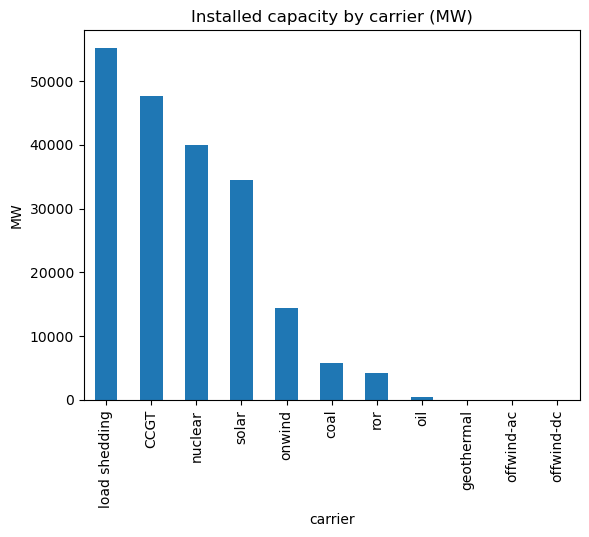

,Energy (MWh)
carrier,
nuclear,1009787.78
solar,156390.36
onwind,155251.44
ror,58968.60
CCGT,1492.52
coal,0.00
geothermal,0.00
load shedding,0.00
offwind-ac,0.00


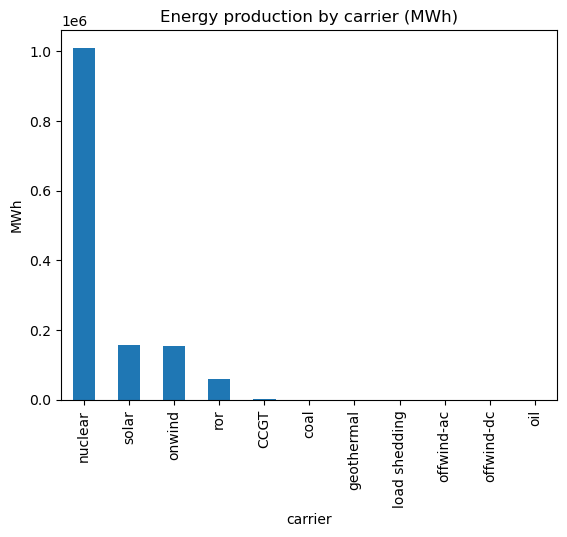

In [35]:
cap = n.generators.groupby("carrier").p_nom_opt.sum().sort_values(ascending=False)
display(cap.to_frame("Installed capacity (MW)").round(2))
ax = cap.plot(kind="bar", title="Installed capacity by carrier (MW)")
plt.ylabel("MW")
plt.show()

energy = n.generators_t.p.sum().groupby(n.generators.carrier).sum().sort_values(ascending=False)
display(energy.to_frame("Energy (MWh)").round(2))
ax = energy.plot(kind="bar", title="Energy production by carrier (MWh)")
plt.ylabel("MWh")
plt.show()

### Installed Generation Mix per Bus
Circle size ∝ total installed capacity at the bus; colors by carrier.

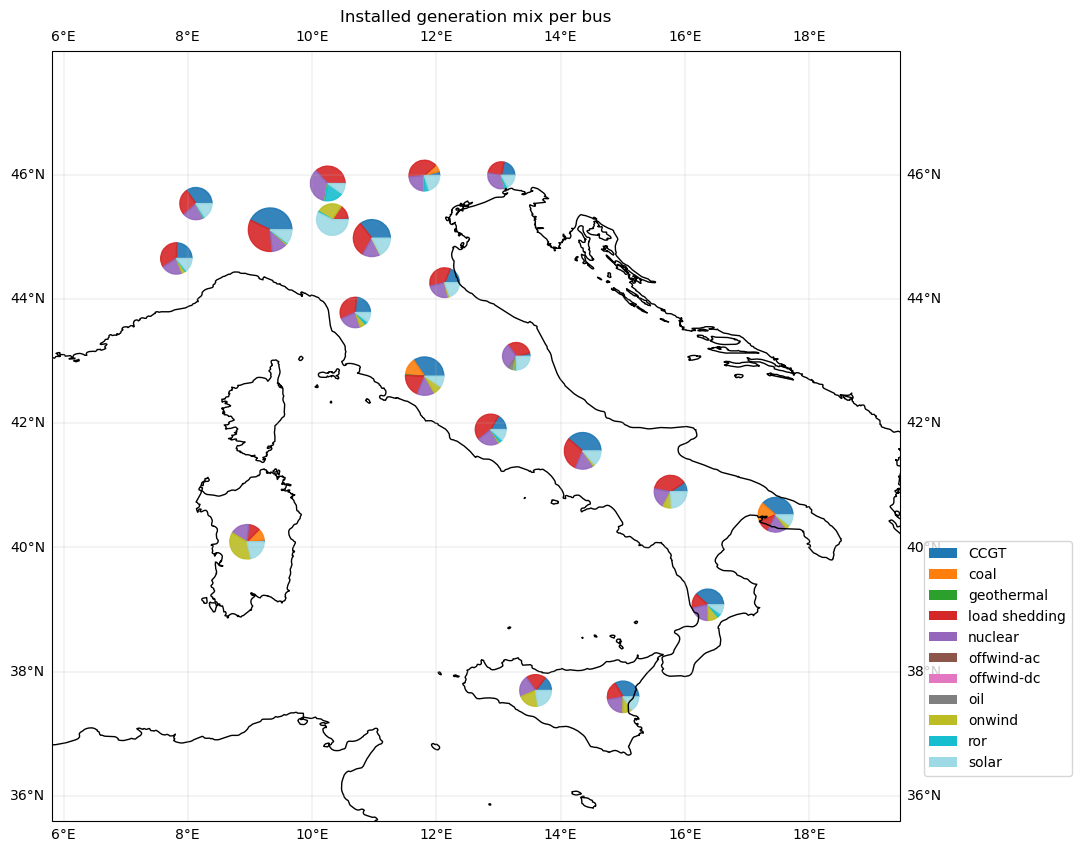

In [36]:
if GIS_AVAILABLE:
    gen = n.generators.groupby(["bus","carrier"]).p_nom_opt.sum().unstack().fillna(0)
    bus_pos = n.buses[["x","y"]]
    colors = carrier_colors(gen.columns)

    fig, ax = map_axes("Installed generation mix per bus", n, figsize=(12,10))

    for bus, row in gen.iterrows():
        vals = row[row>0]
        total = vals.sum()
        if total <= 0: continue
        x, y = bus_pos.loc[bus]
        # radius scaling (tune 'scale' if overlap)
        scale = 0.35
        radius = scale * (0.4 + 0.6 * (total / gen.sum(axis=1).max()))
        start = 0.0
        for carrier, val in vals.items():
            frac = val/total
            wedge = Wedge((x,y), radius, start*360, (start+frac)*360, color=colors[carrier], alpha=0.9)
            ax.add_patch(wedge)
            start += frac

    legend_handles = [Patch(facecolor=colors[c], label=c) for c in gen.columns]
    ax.legend(handles=legend_handles, loc="lower left", bbox_to_anchor=(1.02, 0.05))
    plt.show()
else:
    print("GIS not available — skipping mix pies.")

## Nodal Prices (LMP)
Average marginal price per bus across the simulation horizon.

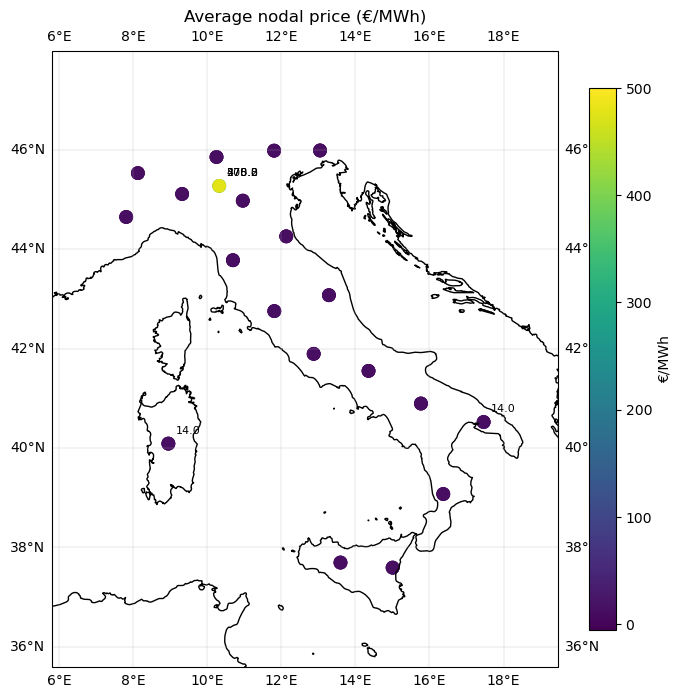

In [37]:
try:
    prices = n.buses_t.marginal_price.mean()
except Exception as e:
    prices = None
    print("No marginal prices:", e)

if prices is not None and GIS_AVAILABLE:
    bus_gdf = get_bus_gdf(n).assign(price = prices.reindex(n.buses.index).values)
    fig, ax = map_axes("Average nodal price (€/MWh)", n)
    bus_gdf.plot(ax=ax, column="price", cmap="viridis", markersize=80, legend=False)
    scalar_colorbar(ax, bus_gdf["price"].min(), bus_gdf["price"].max(), "viridis", "€/MWh")
    # Annotate top-5 expensive nodes
    for idx, r in bus_gdf.sort_values("price", ascending=False).head(5).iterrows():
        ax.text(r.geometry.x+0.2, r.geometry.y+0.2, f"{r['price']:.1f}", fontsize=8)
    plt.show()
elif prices is None:
    print("Prices not available.")
else:
    print("GIS not available.")

## Curtailment per Bus
Potential minus actual renewable generation aggregated by bus.

**Top 10 curtailment (MWh)**

,curtail_MWh
Bus,
IT2 0,9595.92
IT0 16,0.05
IT1 0,0.05
IT0 11,0.03
IT0 1,0.02
IT0 4,0.02
IT0 8,0.02
IT0 13,0.02
IT0 9,0.01


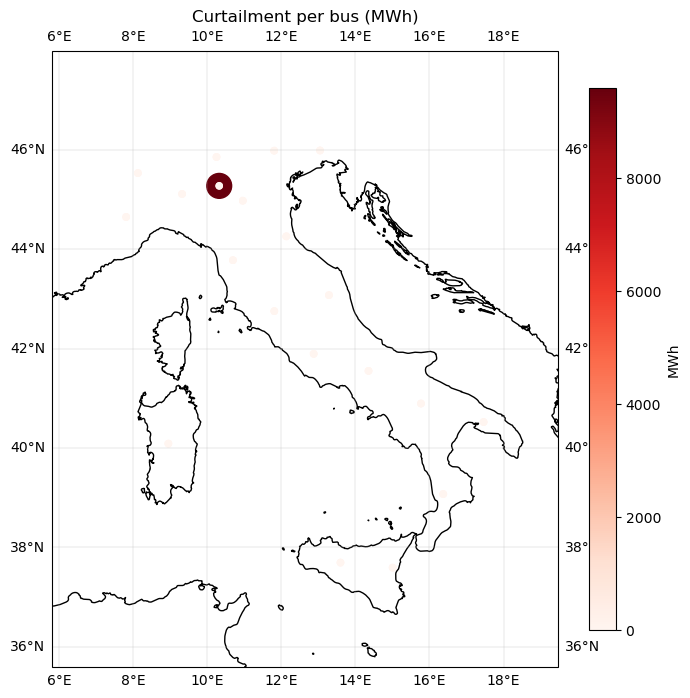

In [38]:
try:
    p_max = n.generators_t.p_max_pu.multiply(n.generators.p_nom_opt, axis=1)
    produced = n.generators_t.p
    curt_by_gen = (p_max - produced).clip(lower=0).sum()
    curt_by_bus = curt_by_gen.groupby(n.generators.bus).sum().reindex(n.buses.index).fillna(0)
except Exception as e:
    curt_by_bus = None
    print("Curtailment not computable:", e)

if curt_by_bus is not None and GIS_AVAILABLE:
    bus_gdf = get_bus_gdf(n).assign(curtail_MWh = curt_by_bus.values)
    fig, ax = map_axes("Curtailment per bus (MWh)", n)
    vmax = max(bus_gdf["curtail_MWh"].max(), 1.0)
    sizes = 20 + (bus_gdf["curtail_MWh"] / vmax) * 300
    bus_gdf.plot(ax=ax, column="curtail_MWh", cmap="Reds", markersize=sizes, legend=False)
    scalar_colorbar(ax, 0, vmax, "Reds", "MWh")
    display(Markdown("**Top 10 curtailment (MWh)**"))
    display(bus_gdf.sort_values("curtail_MWh", ascending=False)[["curtail_MWh"]].head(10).round(2))
    plt.show()
elif curt_by_bus is None:
    print("Curtailment data missing.")
else:
    print("GIS not available.")

## Storage Siting (Power & Energy)
Marker size represents power (MW), color represents energy capacity (MWh).

**Buses with storage (power MW, energy MWh)**

,stor_p_MW,stor_e_MWh
Bus,,
IT0 4,2372.0,0.0
IT0 0,1569.0,0.0
IT0 15,1265.0,0.0
IT0 14,921.0,0.0
IT0 6,629.0,0.0
IT0 13,500.0,0.0
IT0 7,281.0,0.0
IT1 0,240.0,0.0
IT0 3,151.0,0.0


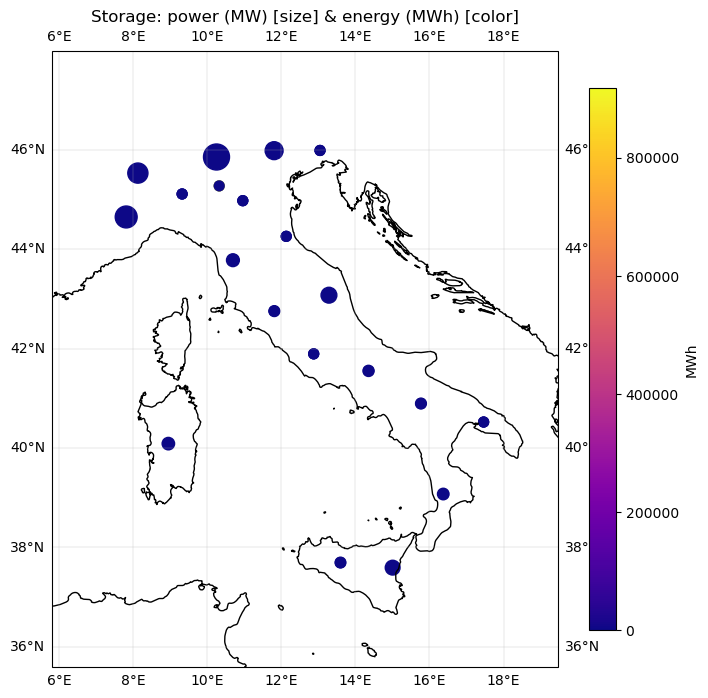

In [39]:
try:
    storage_power = pd.Series(0.0, index=n.buses.index)
    storage_energy = pd.Series(0.0, index=n.buses.index)

    if hasattr(n, "storage_units") and len(n.storage_units) > 0:
        col = "p_nom_opt" if "p_nom_opt" in n.storage_units.columns else "p_nom"
        sp = getattr(n.storage_units, col).groupby(n.storage_units.bus).sum()
        storage_power = storage_power.add(sp.reindex(storage_power.index).fillna(0))

    if hasattr(n, "stores") and len(n.stores) > 0:
        col = "e_nom_opt" if "e_nom_opt" in n.stores.columns else "e_nom"
        se = getattr(n.stores, col).groupby(n.stores.bus).sum()
        storage_energy = storage_energy.add(se.reindex(storage_energy.index).fillna(0))
except Exception as e:
    storage_power = storage_energy = None
    print("Storage computation error:", e)

if storage_power is not None and GIS_AVAILABLE:
    bus_gdf = get_bus_gdf(n).assign(stor_p_MW = storage_power.values,
                                     stor_e_MWh = storage_energy.values)
    fig, ax = map_axes("Storage: power (MW) [size] & energy (MWh) [color]", n)
    vmax = max(bus_gdf["stor_e_MWh"].max(), 1e-6)
    sizes = 50 + (bus_gdf["stor_p_MW"] / max(1, bus_gdf["stor_p_MW"].max())) * 300
    bus_gdf.plot(ax=ax, column="stor_e_MWh", cmap="plasma", markersize=sizes, legend=False)
    scalar_colorbar(ax, 0, vmax, "plasma", "MWh")
    display(Markdown("**Buses with storage (power MW, energy MWh)**"))
    display(bus_gdf[bus_gdf["stor_p_MW"]>0][["stor_p_MW","stor_e_MWh"]].sort_values("stor_p_MW", ascending=False).round(2))
    plt.show()
elif storage_power is None:
    print("No storage data.")
else:
    print("GIS not available.")

## Net Import / Export per Bus
Positive = net exporter over time; Negative = net importer.

**Top exporters (MWh)**

,net_MWh
Bus,
IT0 17,95816.43
IT0 4,62156.64
IT0 13,42610.53
IT0 3,32339.63
IT0 8,29571.80
IT0 16,22091.06
IT0 15,21240.36
IT0 6,14915.58
IT0 14,14812.21


**Top importers (MWh)**

,net_MWh
Bus,
IT0 10,-87840.15
IT0 9,-86332.60
IT0 12,-64331.82
IT0 0,-51249.38
IT0 1,-43580.90
IT0 11,-19386.05
IT0 7,-5049.05
IT1 0,-0.04
IT2 0,-0.02


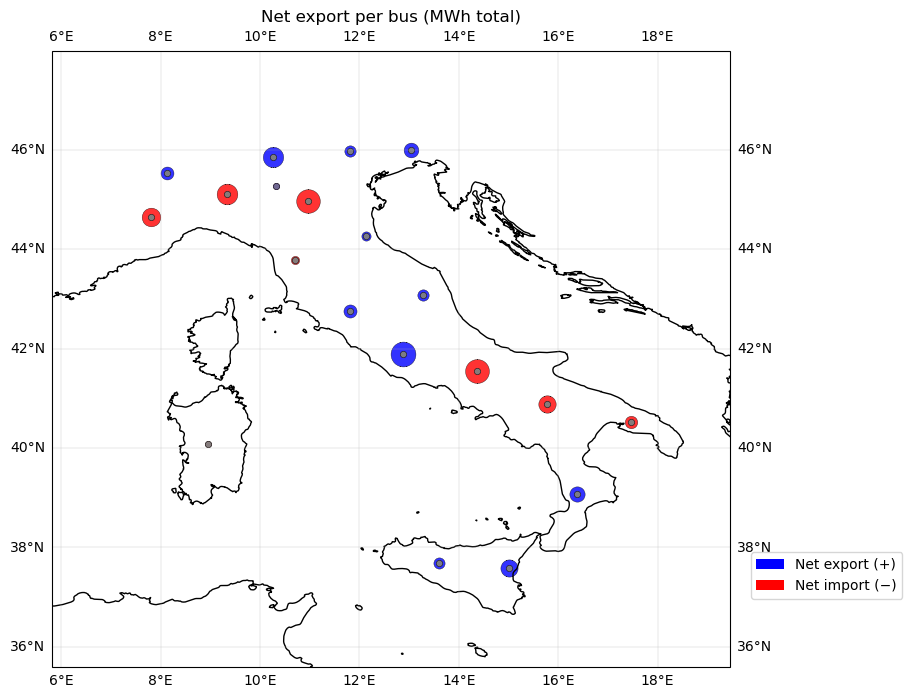

In [40]:
try:
    net = n.buses_t.p.sum()  # positive ~ injection
    net = net.reindex(n.buses.index).fillna(0)
except Exception as e:
    net = None
    print("Net import/export not available:", e)

if net is not None and GIS_AVAILABLE:
    bus_gdf = get_bus_gdf(n).assign(net_MWh = net.values)
    fig, ax = map_axes("Net export per bus (MWh total)", n)
    absv = bus_gdf["net_MWh"].abs()
    sizes = 20 + (absv / max(1, absv.max())) * 300
    for _, r in bus_gdf.iterrows():
        color = "blue" if r["net_MWh"]>0 else ("red" if r["net_MWh"]<0 else "gray")
        ax.scatter(r.geometry.x, r.geometry.y, s=sizes.loc[r.name], color=color,
                   transform=ccrs.PlateCarree(), alpha=0.8, edgecolor="k", linewidth=0.3)
    ax.legend(handles=[Patch(facecolor="blue", label="Net export (+)"),
                       Patch(facecolor="red", label="Net import (−)")],
              loc="lower left", bbox_to_anchor=(1.02, 0.1))
    display(Markdown("**Top exporters (MWh)**"))
    display(bus_gdf.sort_values("net_MWh", ascending=False)[["net_MWh"]].head(10).round(2))
    display(Markdown("**Top importers (MWh)**"))
    display(bus_gdf.sort_values("net_MWh", ascending=True)[["net_MWh"]].head(10).round(2))
    plt.show()
elif net is None:
    print("Net import/export not computable.")
else:
    print("GIS not available.")

## System Energy Balance

In [41]:
try:
    display(n.statistics.energy_balance())
except Exception as e:
    print("energy_balance() not available:", e)

component    carrier             bus_carrier     
Generator    Combined-Cycle Gas  Ac                  3.631787e+05
             Nuclear             Ac                  2.457150e+08
             Onshore Wind        Ac                  3.777785e+07
             Run of River        Ac                  1.434903e+07
             Solar               Ac                  3.805499e+07
StorageUnit  Reservoir & Dam     Ac                  8.165387e+06
Store        Hydrogen Storage    Hydrogen Storage   -3.893330e+00
Load         -                   Ac                 -3.418306e+08
Link         H2 electrolysis     Ac                 -3.765350e+06
                                 Hydrogen Storage    2.340918e+06
             H2 fuel cell        Ac                  1.170457e+06
                                 Hydrogen Storage   -2.340914e+06
dtype: float64

## Costs & LCOE
Notes:
- Some PyPSA-Earth builds remove `statistics.capex/opex`; we compute LCOE manually.
- CAPEX is annualised; OPEX is variable cost times energy.

System LCOE: 29865.26 €/MWh


,CAPEX €/y,OPEX €/y,Energy MWh,LCOE €/MWh
carrier,,,,
CCGT,4.997171e+09,69869.17,1492.52,3348201.20
coal,1.965923e+09,0.00,0.00,inf
geothermal,0.000000e+00,0.00,0.00,NaN
load shedding,0.000000e+00,0.00,0.00,NaN
nuclear,3.015137e+10,14161328.23,1009787.78,29873.14
offwind-ac,0.000000e+00,0.00,0.00,NaN
offwind-dc,0.000000e+00,0.00,0.00,NaN
oil,1.559613e+07,0.00,0.00,inf
onwind,1.466123e+09,3785.07,155251.44,9443.56


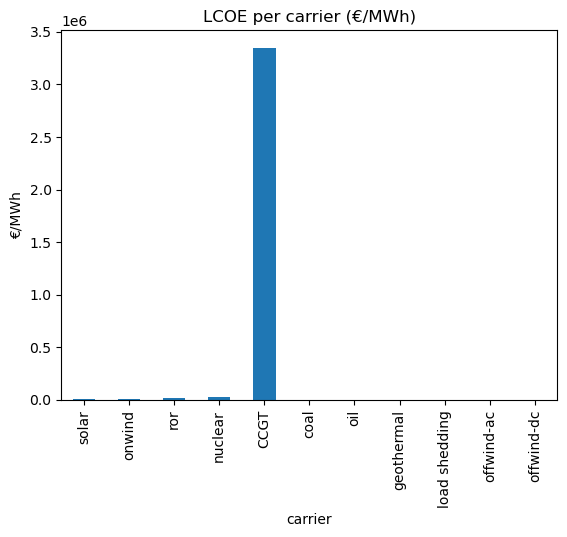

In [42]:
from IPython.display import display
import matplotlib.pyplot as plt

def compute_lcoe(n, exclude_storage=True, plot=True):
    # Carrier labeling safety
    n.generators["carrier"] = n.generators.carrier.fillna("unknown")

    # Total energy by carrier
    energy = (
        n.generators_t.p
        .groupby(n.generators.carrier, axis=1)
        .sum()
        .sum()
    )

    # CAPEX (annualised) by carrier
    capex = (
        n.generators.p_nom_opt * n.generators.capital_cost
    ).groupby(n.generators.carrier).sum()

    # OPEX (variable cost × energy)
    opex = (
        n.generators_t.p
        .groupby(n.generators.carrier, axis=1)
        .sum()
        * n.generators.marginal_cost.groupby(n.generators.carrier).first()
    ).sum()

    # Optional: ignore storage-like carriers
    if exclude_storage:
        storage_like = [
            "battery", "battery charger", "battery discharger",
            "h2", "hydrogen", "electrolysis", "fuel cell"
        ]
        mask = ~energy.index.str.lower().str.contains("|".join(storage_like), regex=True)
        capex = capex[mask]
        opex = opex[mask]
        energy = energy[mask]

    lcoe_carrier = (capex + opex) / energy
    lcoe_total = (capex.sum() + opex.sum()) / energy.sum()

    print(f"System LCOE: {lcoe_total:.2f} €/MWh")

    display(pd.DataFrame({
        "CAPEX €/y": capex.round(2),
        "OPEX €/y": opex.round(2),
        "Energy MWh": energy.round(2),
        "LCOE €/MWh": lcoe_carrier.round(2),
    }))

    if plot:
        lcoe_carrier.sort_values().plot(kind="bar", title="LCOE per carrier (€/MWh)")
        plt.ylabel("€/MWh")
        plt.show()

    return lcoe_total, lcoe_carrier

# Run
lcoe_total, lcoe_carrier = compute_lcoe(n)

## Emissions
CO₂ constraint and realised emissions by carrier.

In [43]:
try:
    co2_limit_Mt = n.global_constraints.loc["CO2Limit","constant"] / 1e6
    mu = n.global_constraints.loc["CO2Limit","mu"]
    print(f"CO₂ limit: {co2_limit_Mt:.2f} Mt, mu (shadow price): {mu:.2f} €/t")
except Exception as e:
    print("No CO₂ global constraint:", e)

try:
    emissions = (
        n.generators_t.p
        .multiply(n.generators.efficiency.reindex(n.generators_t.p.columns))
        .multiply(n.generators.carrier.map(n.carriers.co2_emissions))
    ).sum().sum()
    print(f"Realised emissions: {emissions/1e6:.2f} MtCO₂")
    emissions_by_carrier = (
        n.generators_t.p
        .multiply(n.generators.carrier.map(n.carriers.co2_emissions))
        .sum()
        .groupby(n.generators.carrier).sum()
        .sort_values(ascending=False)
    )
    display(emissions_by_carrier.div(1e6).to_frame("MtCO₂").round(3))
except Exception as e:
    print("Emission computation failed:", e)

CO₂ limit: 0.12 Mt, mu (shadow price): -232.02 €/t
Realised emissions: 0.00 MtCO₂


,MtCO₂
carrier,
CCGT,0.0
coal,0.0
geothermal,0.0
load shedding,0.0
nuclear,0.0
offwind-ac,0.0
offwind-dc,0.0
oil,0.0
onwind,0.0
